In [1]:
from pathlib import Path
from dataclasses import dataclass
from scipy.stats import chi2
from typing import *

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np


pd.set_option("display.precision", 10)


ROOT_DIR = Path(os.getcwd()).parent

In [2]:
@dataclass
class PumpEvent:
    ticker: str
    pump_time: str

    def __post_init__(self):
        self.pump_time = pd.Timestamp(self.pump_time)


def create_date_range(start: pd.Timestamp, end: pd.Timestamp) -> List[str]:
    """Creates a range of months and years between two dates"""
    start_year = start.year
    start_month = start.month
    end_year = end.year
    end_month = end.month

    date_range = []

    for year in range(start_year, end_year + 1):
        start_month_range = start_month if year == start_year else 1
        end_month_range = end_month if year == end_year else 12

        for month in range(start_month_range, end_month_range + 1):
            date_range.append(pd.Timestamp(year=year, month=month, day=1))

    return date_range


def load_data(pump_event: PumpEvent, lookback_delta: pd.Timedelta) -> pd.DataFrame:
    rb = pump_event.pump_time
    lb = rb - lookback_delta

    ts_range: List[pd.Timestamp] = create_date_range(start=lb, end=rb)

    # ./data/trades/1INCHBTC
    TICKER_DIR = os.path.join(ROOT_DIR, "data/trades", pump_event.ticker)
    df = pd.DataFrame()

    for date in ts_range:
        month, year = str(date.month).zfill(2), date.year
        # 1INCHBTC-2021-09.parquet
        slug = f"{pump_event.ticker}-{year}-{str(month).zfill(2)}.parquet"
        df_tmp = pd.read_parquet(os.path.join(TICKER_DIR, slug))

        df = pd.concat([df, df_tmp], axis=0)

    df = df[df["time"] >= pump_event.pump_time - lookback_delta].copy()
    df = df.reset_index(drop=True)
    
    return df

In [3]:
df_pumps = pd.read_csv(os.path.join(ROOT_DIR, "data/pumps/cleaned/pumps_verified.csv"))
df_pumps["time"] = pd.to_datetime(df_pumps["time"])
df_pumps.tail(10)

,ticker,time,source
119,MTHBTC,2021-11-07 17:00:03,telegram
120,MDABTC,2021-11-23 15:00:24,telegram
121,PHBBTC,2021-11-28 17:00:05,telegram
122,APPCBTC,2021-12-19 15:00:19,telegram
123,OAXBTC,2021-12-28 15:00:16,telegram
124,NEBLBTC,2022-01-02 17:00:07,telegram
125,SNMBTC,2022-01-27 15:02:16,telegram
126,NASBTC,2022-02-01 15:01:54,telegram
127,WANBTC,2022-07-03 16:00:30,telegram
128,AGIXBTC,2022-08-14 16:00:05,telegram


In [4]:
def plot_pump_ts(df: pd.DataFrame, ticker: str):
    pumps_ts: List[pd.Timestamp] = df_pumps[df_pumps["ticker"] == ticker]["time"].tolist()
    times = [
        ts for ts in pumps_ts if ts >= min(df["time"]) and ts <= max(df["time"])
    ]
    for time in times:
        plt.axvline(x=time, linestyle="--", color="black")

    return times

In [5]:
pump = PumpEvent(ticker="AERGOBTC", pump_time="2022-01-02 17:00:07")

df = load_data(pump_event=pump, lookback_delta=pd.Timedelta(days=30))
df.head()

,trade_id,price,qty,time,isBuyerMaker
0,3739735,0.00000713,245.0,2021-12-03 17:02:19.066,True
1,3739736,0.00000716,57.0,2021-12-03 17:04:45.102,False
2,3739737,0.00000716,23.0,2021-12-03 17:10:33.684,False
3,3739738,0.00000716,144.0,2021-12-03 17:10:33.684,False
4,3739739,0.00000713,80.0,2021-12-03 17:10:37.161,True


In [6]:
df["qty_sign"] = df["qty"] * (1 - 2 * df["isBuyerMaker"])

df_group = df.groupby("time").agg(
    {
        "price": ["first", "min", "mean", "max", "last"],
        "trade_id": ["count"],
        "isBuyerMaker": ["mean"],
        "qty": ["sum"],
        "qty_sign": ["sum"],
    }
)

df_group.columns = df_group.columns.map("_".join)
df_group["time"] = df_group.index
df_group.shape

(74335, 10)

In [7]:
# Check how valid our assumption trade aggregation is
df_group["isBuyerMaker_mean"].value_counts()

isBuyerMaker_mean
0.0000000000    37509
1.0000000000    36796
0.5000000000       16
0.6666666667        2
0.8000000000        2
0.0666666667        1
0.9565217391        1
0.9615384615        1
0.3333333333        1
0.9642857143        1
0.9411764706        1
0.0769230769        1
0.9333333333        1
0.0416666667        1
0.7500000000        1
Name: count, dtype: int64

<h4>Features</h4>

<h4>Whale features</h4>

In [8]:
window = "7D"

is_whale_condition = df_group["qty_sum"] >= df_group.rolling(window)["qty_sum"].quantile(.999)
buy_condition = df_group["qty_sign_sum"] > 0
before_pump = df_group["time"] < pump.pump_time

<h4>Whale volume imbalance</h4>

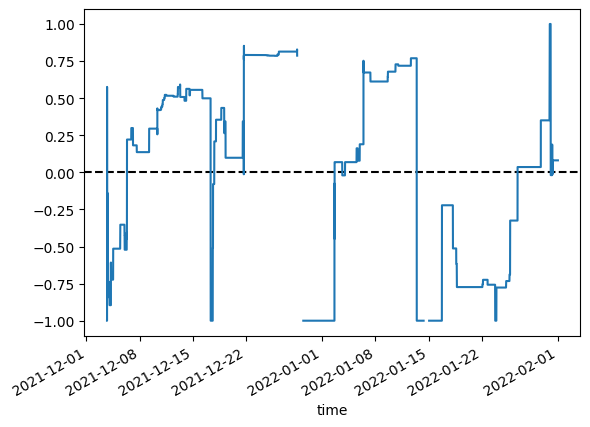

In [9]:
df_group["whale_net_position"] = (
    df_group["qty_sign_sum"] * is_whale_condition
).rolling(window).sum()

df_group["whale_position"] = (
    df_group["qty_sum"] * is_whale_condition
).rolling(window).sum()

plt.axhline(y=0, linestyle="--", color="black")

df_group["whale_imbalance"] = df_group["whale_net_position"] / df_group["whale_position"]
df_group["whale_imbalance"].plot()

plot_pump_ts(df=df_group, ticker=pump.ticker)
plt.show()

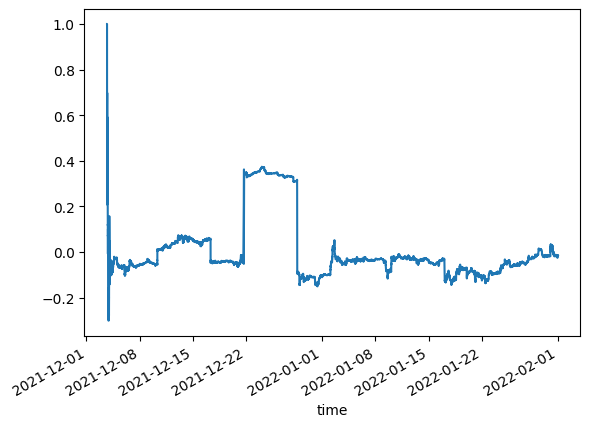

In [10]:
df_group["whale_net_position"] = (
    (df_group["qty_sign_sum"] * ~is_whale_condition).rolling(window).sum()
)

df_group["whale_position"] = (
    (df_group["qty_sum"] * ~is_whale_condition).rolling(window).sum()
)

df_group["whale_imbalance"] = (
    df_group["whale_net_position"] / df_group["whale_position"]
)
df_group["whale_imbalance"].plot()

# plot_pump_ts(df=df_group, ticker=pump.ticker)
plt.show()

<h4>When do whales buy?</h4>

In [11]:
pump.pump_time.weekday()

6

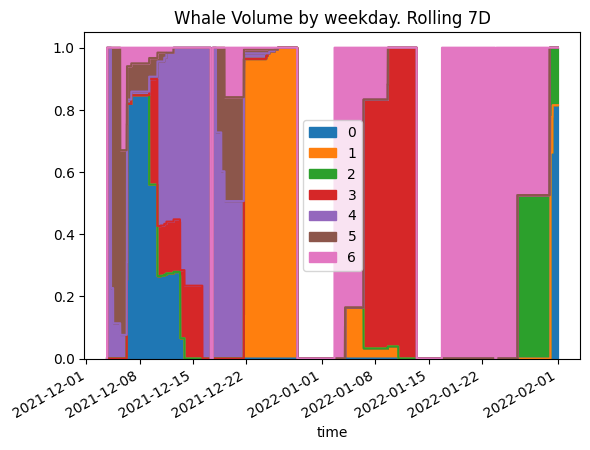

In [12]:
df_group["weekday"] = df_group["time"].dt.weekday

df_weekdays = pd.get_dummies(df_group["weekday"])
df_weekdays = df_weekdays.mul(df_group["qty_sum"] * is_whale_condition * buy_condition, axis=0)

df_weekdays = df_weekdays.rolling(window).sum()
df_weekdays = df_weekdays.div(
    (df_group["qty_sum"] * is_whale_condition * buy_condition).rolling(window).sum(), axis=0
)

df_weekdays.plot.area()
plot_pump_ts(df=df_group, ticker=pump.ticker)

plt.title(f"Whale Volume by weekday. Rolling {window}")
plt.show()

<h4>Regular volume by weekday</h4>

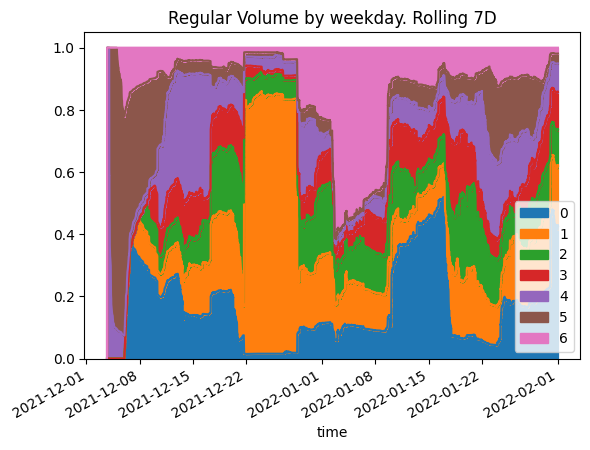

In [13]:
df_weekdays = pd.get_dummies(df_group["weekday"])
df_weekdays = df_weekdays.mul(
    df_group["qty_sum"] * ~is_whale_condition * buy_condition, axis=0
)

df_weekdays = df_weekdays.rolling(window).sum()
df_weekdays = df_weekdays.div(
    (df_group["qty_sum"] * ~is_whale_condition * buy_condition).rolling(window).sum(),
    axis=0,
)

df_weekdays.plot.area()
plot_pump_ts(df=df_group, ticker=pump.ticker)
plt.title(f"Regular Volume by weekday. Rolling {window}")
plt.show()

<h4>Whale volume by hour of the day</h4>

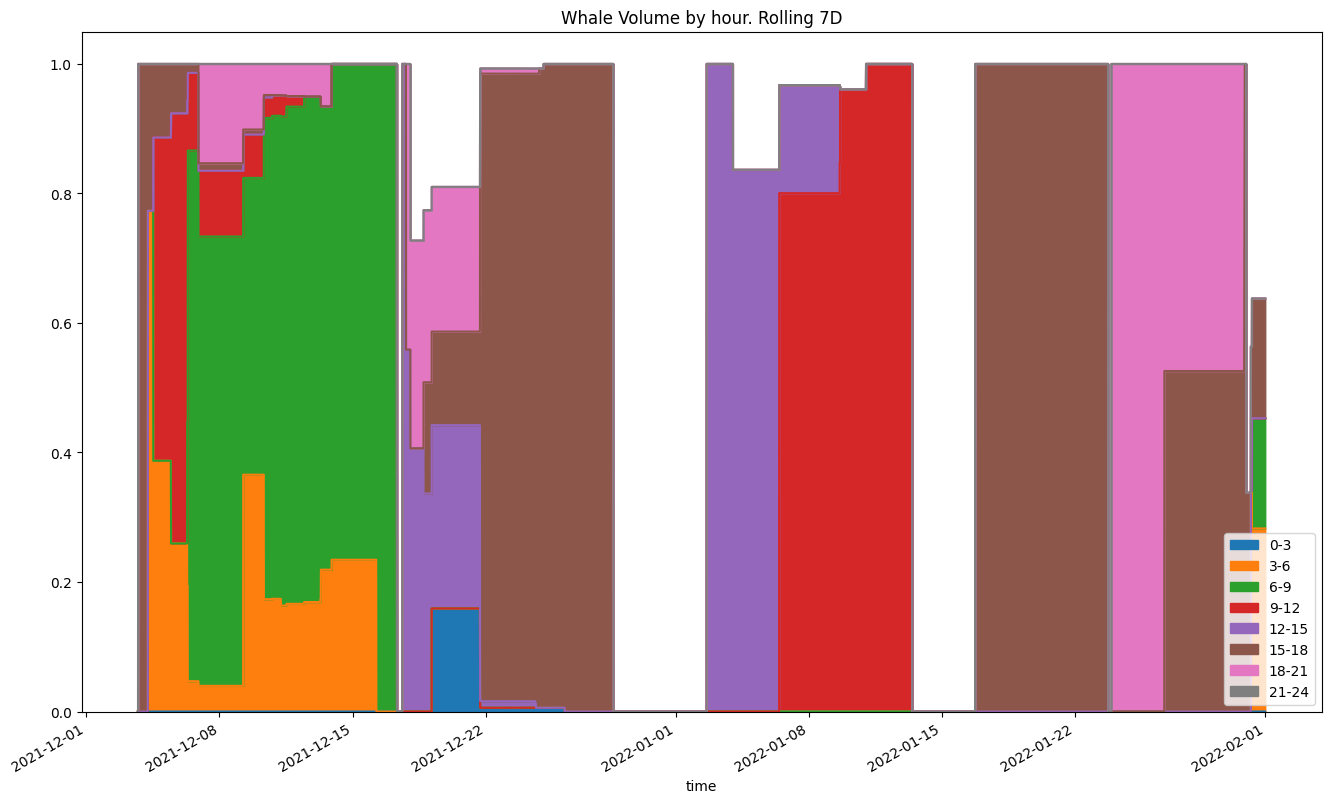

In [14]:
df_group["hour"] = df_group["time"].dt.hour
bin_hours = [0, 3, 6, 9, 12, 15, 18, 21, 24]

df_group["day_period"] = pd.cut(
    df_group["hour"], bins=bin_hours, 
    labels=["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"]
)

df_hours = pd.get_dummies(df_group["day_period"])
df_hours = df_hours.mul(df_group["qty_sum"] * is_whale_condition * buy_condition, axis=0)

df_hours = df_hours.rolling(window).sum()
df_hours = df_hours.div(
    (df_group["qty_sum"] * is_whale_condition * buy_condition).rolling(window).sum(), axis=0
)

df_hours.plot.area(figsize=(16, 10))
plot_pump_ts(df=df_group, ticker=pump.ticker)

plt.title(f"Whale Volume by hour. Rolling {window}")
plt.show()

<h4>Benford's Law</h4>

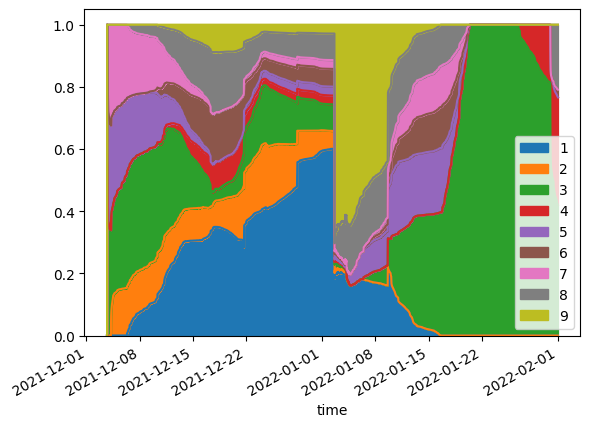

In [15]:
df_group["qty_first_digit"] = df_group["qty_sum"].astype(str).str[0].astype(int)

df_digits = pd.get_dummies(df_group["qty_first_digit"])
# Count digit in whale trades on buy side
df_digits = df_digits.mul(
    is_whale_condition * buy_condition, axis=0
).rolling(window).sum()

df_sm = df_digits.div(
    (is_whale_condition * buy_condition).rolling(window).sum(), axis=0
)
# As a result we get rolling frequences of each digit as the first number
df_sm.rolling(window).mean().plot.area()
plt.show()

In [16]:
df_expected_freq = pd.DataFrame()

expected_freq = pd.Series([
    np.log(i+1) - np.log(i) for i in range(1, 10)
])

rolling_overall_trades = (is_whale_condition * buy_condition).rolling(window).sum()

for i in range(1, 10):
    df_expected_freq[i] = expected_freq[i-1] * rolling_overall_trades

df_expected_freq.tail(2)

,1,2,3,4,5,6,7,8,9
time,,,,,,,,,
2022-01-31 23:54:36.631,2.7725887222,1.6218604324,1.1507282898,0.8925742053,0.7292862272,0.6166027193,0.5341255705,0.4711321426,0.4214420626
2022-01-31 23:58:11.484,2.7725887222,1.6218604324,1.1507282898,0.8925742053,0.7292862272,0.6166027193,0.5341255705,0.4711321426,0.4214420626


<h4>Chi2 test for significance of differences of frequences</h4>

$\chi^2_{\text{stat}} = \frac{\sum_{i=1}^N{(\text{Observed - Expected})^2}}{Expected}$ </br>
</br>
$H_0: \text{There is no connection between frequencies, i.e Benfard's law does not hold}$

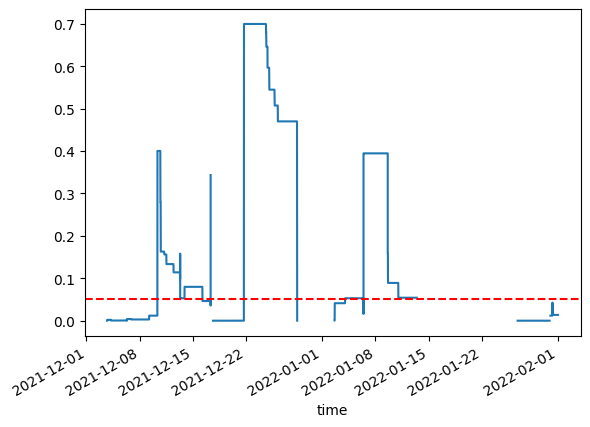

In [17]:
from scipy.stats import chi2

chi_square_stats = np.sum(
    (df_digits - df_expected_freq).div(df_expected_freq, axis=0), axis=1
)**2

pval = 1 - chi2.cdf(chi_square_stats, df=rolling_overall_trades-1)

df_digits["pval"] = pval
df_digits["pval"].plot()

plot_pump_ts(df_group, ticker=pump.ticker)
plt.axhline(y=0.05, color="red", linestyle="--")
plt.show()

[]

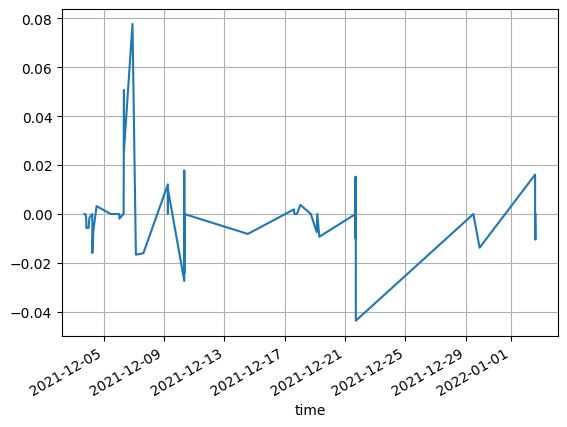

In [18]:
df_group["price_slippage"] = df_group["price_max"] / df_group["price_min"] - 1
df_group["price_slippage"] = df_group["price_slippage"] * (1 - 2*(df_group["isBuyerMaker_mean"] > 0.5))

df_group["price_slippage"][
    is_whale_condition & before_pump
].plot()

plt.grid()

plot_pump_ts(df_group, ticker=pump.ticker)

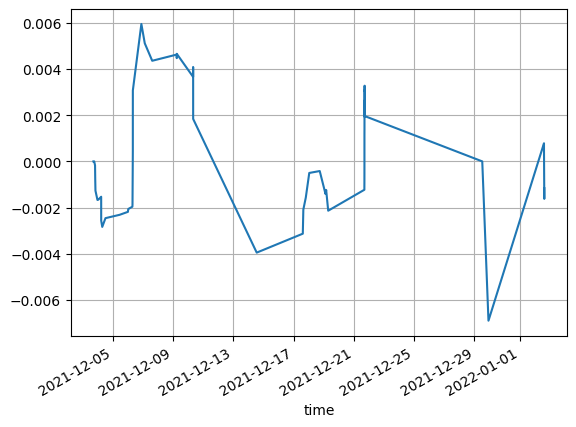

In [19]:
before_pump = df_group["time"] < pump.pump_time

df_group["price_slippage"][is_whale_condition & before_pump].rolling(window).mean().plot()
plot_pump_ts(df_group, pump.ticker)

plt.grid()
plt.show()

In [20]:
# Create features

def create_features(df_group: pd.DataFrame, window: str):
    before_pump = df_group["time"] < pump.pump_time - pd.Timedelta(minutes=15)

    df_group = df_group[before_pump].copy()

    is_whale_condition = df_group["qty_sum"] >= df_group.rolling(window)[
        "qty_sum"
    ].quantile(0.999)

    buy_condition = df_group["qty_sign_sum"] > 0

    # Whale imbalance ratio
    df_group["whale_net_position"] = (
        (df_group["qty_sign_sum"] * is_whale_condition).rolling(window).sum()
    )
    df_group["whale_position"] = (
        (df_group["qty_sum"] * is_whale_condition).rolling(window).sum()
    )
    df_group["whale_imbalance"] = (
        df_group["whale_net_position"] / df_group["whale_position"]
    )

    # Regular imbalance ratio
    df_group["regular_net_position"] = (
        (df_group["qty_sign_sum"] * ~is_whale_condition).rolling(window).sum()
    )
    df_group["regular_position"] = (
        (df_group["qty_sum"] * ~is_whale_condition).rolling(window).sum()
    )
    df_group["regular_volume_imbalance"] = (
        df_group["regular_net_position"] / df_group["regular_position"]
    )

    # Weekdays of whale volume
    df_group["weekday"] = df_group["time"].dt.weekday

    df_weekdays = pd.get_dummies(df_group["weekday"])
    df_weekdays = df_weekdays.mul(
        df_group["qty_sum"] * is_whale_condition * buy_condition, axis=0
    )

    df_weekdays = df_weekdays.rolling(window).sum()
    df_weekdays = df_weekdays.div(
        (df_group["qty_sum"] * is_whale_condition * buy_condition).rolling(window).sum(),
        axis=0,
    )

    whale_weekdays_cols = [f"whale_vol_weekday_{i}" for i in range(7)]

    df_weekdays.columns = whale_weekdays_cols
    df_group = pd.concat([df_group, df_weekdays], axis=1)

    # Regular volume by weekday
    df_weekdays = pd.get_dummies(df_group["weekday"])
    df_weekdays = df_weekdays.mul(
        df_group["qty_sum"] * ~is_whale_condition * buy_condition, axis=0
    )

    df_weekdays = df_weekdays.rolling(window).sum()
    df_weekdays = df_weekdays.div(
        (df_group["qty_sum"] * ~is_whale_condition * buy_condition).rolling(window).sum(),
        axis=0,
    )

    regular_weekdays_cols = [f"regular_vol_weekday_{i}" for i in range(7)]
    df_weekdays.columns = regular_weekdays_cols
    df_group = pd.concat([df_group, df_weekdays], axis=1)

    # Whale volume by hour
    df_group["hour"] = df_group["time"].dt.hour
    bin_hours = [0, 3, 6, 9, 12, 15, 18, 21, 24]
    labels = ["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"]

    df_group["day_period"] = pd.cut(
        df_group["hour"],
        bins=bin_hours,
        labels=labels,
    )

    df_hours = pd.get_dummies(df_group["day_period"])
    df_hours = df_hours.mul(
        df_group["qty_sum"] * is_whale_condition * buy_condition, axis=0
    )
    df_hours = df_hours.rolling(window).sum()
    df_hours = df_hours.div(
        (df_group["qty_sum"] * is_whale_condition * buy_condition).rolling(window).sum(),
        axis=0,
    )

    whale_hours_cols = [f"whale_vol_{label}" for label in labels]
    df_hours.columns = whale_hours_cols

    df_group = pd.concat([df_group, df_hours], axis=1)

    # Benfard's Law

    df_group["qty_first_digit"] = df_group["qty_sum"].astype(str).str[0].astype(int)

    df_digits = pd.get_dummies(df_group["qty_first_digit"])
    # Count digit in whale trades on buy side
    df_digits = df_digits.mul(
        is_whale_condition * buy_condition, axis=0
    ).rolling(window).sum()

    # Calculate expected frequencies
    df_expected_freq = pd.DataFrame()

    expected_freq = pd.Series([np.log(i + 1) - np.log(i) for i in range(1, 10)])
    rolling_overall_trades = (is_whale_condition * buy_condition).rolling(window).sum()

    for i in range(1, 10):
        df_expected_freq[i] = expected_freq[i - 1] * rolling_overall_trades

    chi_square_stats = np.sum(
        (df_digits - df_expected_freq).div(df_expected_freq, axis=0), axis=1
    )**2

    pval = 1 - chi2.cdf(chi_square_stats, df=rolling_overall_trades-1)

    df_digits["pval"] = pval

    df_group["pval"] = df_digits["pval"]
    
    return df_group[
        ["whale_imbalance", "regular_volume_imbalance"] + whale_weekdays_cols 
        + regular_weekdays_cols + whale_hours_cols
    ]

In [21]:
df["qty_sign"] = df["qty"] * (1 - 2 * df["isBuyerMaker"])

df_group = df.groupby("time").agg(
    {
        "price": ["first", "min", "mean", "max", "last"],
        "trade_id": ["count"],
        "isBuyerMaker": ["mean"],
        "qty": ["sum"],
        "qty_sign": ["sum"],
    }
)

df_group.columns = df_group.columns.map("_".join)
df_group["time"] = df_group.index
df_group.head()

,price_first,price_min,price_mean,price_max,price_last,trade_id_count,isBuyerMaker_mean,qty_sum,qty_sign_sum,time
time,,,,,,,,,,
2021-12-03 17:02:19.066,0.00000713,0.00000713,0.00000713,0.00000713,0.00000713,1,1.0,245.0,-245.0,2021-12-03 17:02:19.066
2021-12-03 17:04:45.102,0.00000716,0.00000716,0.00000716,0.00000716,0.00000716,1,0.0,57.0,57.0,2021-12-03 17:04:45.102
2021-12-03 17:10:33.684,0.00000716,0.00000716,0.00000716,0.00000716,0.00000716,2,0.0,167.0,167.0,2021-12-03 17:10:33.684
2021-12-03 17:10:37.161,0.00000713,0.00000713,0.00000713,0.00000713,0.00000713,1,1.0,80.0,-80.0,2021-12-03 17:10:37.161
2021-12-03 17:14:30.700,0.00000716,0.00000716,0.00000716,0.00000716,0.00000716,2,0.0,321.0,321.0,2021-12-03 17:14:30.700


In [22]:
df_features = create_features(df_group=df_group, window="7D")
df_roll = df_features.rolling("1D").agg(["median", "max"])
df_roll.columns = df_roll.columns.map("_".join)

In [23]:
df_res = pd.DataFrame()

for i in range(1, 24*14+1):
    after_threshold = (
        df_roll.index >= pump.pump_time - pd.Timedelta(minutes=15) - pd.Timedelta(hours=i)
    )
    df_res = pd.concat(
        [df_res, df_roll[after_threshold].iloc[0].to_frame()], axis=1
    )

In [24]:
df_res = df_res.T

df_res.index = [f"{i}_H" for i in range(1, 24*14+1)]
df_res

,whale_imbalance_median,whale_imbalance_max,regular_volume_imbalance_median,regular_volume_imbalance_max,whale_vol_weekday_0_median,whale_vol_weekday_0_max,whale_vol_weekday_1_median,whale_vol_weekday_1_max,whale_vol_weekday_2_median,whale_vol_weekday_2_max,...,whale_vol_9-12_median,whale_vol_9-12_max,whale_vol_12-15_median,whale_vol_12-15_max,whale_vol_15-18_median,whale_vol_15-18_max,whale_vol_18-21_median,whale_vol_18-21_max,whale_vol_21-24_median,whale_vol_21-24_max
1_H,-1.0000000000,0.0686667637,0.0211823685,0.0520193923,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0000000000,1.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0,0.0
2_H,-1.0000000000,-1.0000000000,0.0162209294,0.0504029849,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3_H,-1.0000000000,-1.0000000000,0.0090146507,0.0264214318,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4_H,-1.0000000000,-1.0000000000,0.0086237849,0.0264214318,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5_H,-1.0000000000,-1.0000000000,0.0069604897,0.0264214318,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332_H,0.0982207051,0.4341444767,-0.0411788750,-0.0370341798,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2830888641,0.3366768609,0.1444344180,0.1717754833,0.2234725835,0.2657753711,0.0,0.0
333_H,0.2640445453,0.4341444767,-0.0413078460,-0.0370341798,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2830888641,0.3366768609,0.1444344180,0.1717754833,0.2234725835,0.2657753711,0.0,0.0
334_H,0.2640445453,0.4341444767,-0.0414122603,-0.0370341798,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2830888641,0.3366768609,0.1444344180,0.1717754833,0.2234725835,0.2657753711,0.0,0.0
335_H,0.2640445453,0.4341444767,-0.0413317387,-0.0370341798,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.3366768609,0.3366768609,0.1717754833,0.1717754833,0.2657753711,0.2657753711,0.0,0.0


In [25]:
df_res = df_res.unstack().to_frame().sort_index(level=1).T
df_res.columns = df_res.columns.map("_".join)
df_res

,regular_vol_weekday_0_max_100_H,regular_vol_weekday_0_median_100_H,regular_vol_weekday_1_max_100_H,regular_vol_weekday_1_median_100_H,regular_vol_weekday_2_max_100_H,regular_vol_weekday_2_median_100_H,regular_vol_weekday_3_max_100_H,regular_vol_weekday_3_median_100_H,regular_vol_weekday_4_max_100_H,regular_vol_weekday_4_median_100_H,...,whale_vol_weekday_2_max_9_H,whale_vol_weekday_2_median_9_H,whale_vol_weekday_3_max_9_H,whale_vol_weekday_3_median_9_H,whale_vol_weekday_4_max_9_H,whale_vol_weekday_4_median_9_H,whale_vol_weekday_5_max_9_H,whale_vol_weekday_5_median_9_H,whale_vol_weekday_6_max_9_H,whale_vol_weekday_6_median_9_H
0,0.1018581429,0.0969160275,0.817789849,0.1921695567,0.2820084138,0.1483393408,0.0817594589,0.0777925235,0.2404384127,0.2287724395,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df_features.T

time,2021-12-03 17:02:19.066,2021-12-03 17:04:45.102,2021-12-03 17:10:33.684,2021-12-03 17:10:37.161,2021-12-03 17:14:30.700,2021-12-03 17:15:49.715,2021-12-03 17:15:49.728,2021-12-03 17:15:52.740,2021-12-03 17:16:33.064,2021-12-03 17:16:46.841,...,2022-01-02 16:41:09.071,2022-01-02 16:41:14.462,2022-01-02 16:41:49.457,2022-01-02 16:43:05.649,2022-01-02 16:43:29.834,2022-01-02 16:43:35.319,2022-01-02 16:44:21.577,2022-01-02 16:44:27.814,2022-01-02 16:44:27.922,2022-01-02 16:45:02.958
whale_imbalance,-1.0,-1.0,-1.0,-1.0000000000,0.1342756184,0.1342756184,0.1342756184,0.1342756184,0.1342756184,0.5757575758,...,0.0686667637,0.0686667637,0.0686667637,0.0686667637,0.0686667637,0.0686667637,0.0686667637,0.0686667637,0.0686667637,0.0686667637
regular_volume_imbalance,NaN,1.0,1.0,0.4736842105,0.4736842105,0.7080291971,0.7546012270,0.8214285714,0.8452611219,0.8452611219,...,-0.0173091685,-0.0173043415,-0.0173158429,-0.0173336646,-0.0174372657,-0.0174392339,-0.0175600049,-0.0175646652,-0.0176161335,-0.0175880305
whale_vol_weekday_0,NaN,NaN,NaN,NaN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
whale_vol_weekday_1,NaN,NaN,NaN,NaN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
whale_vol_weekday_2,NaN,NaN,NaN,NaN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
whale_vol_weekday_3,NaN,NaN,NaN,NaN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
whale_vol_weekday_4,NaN,NaN,NaN,NaN,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
whale_vol_weekday_5,NaN,NaN,NaN,NaN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
whale_vol_weekday_6,NaN,NaN,NaN,NaN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000
regular_vol_weekday_0,NaN,0.0,0.0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,...,0.0596141519,0.0596135762,0.0596135762,0.0596135762,0.0596135762,0.0596135762,0.0596135762,0.0596135762,0.0596135762,0.0596102247
